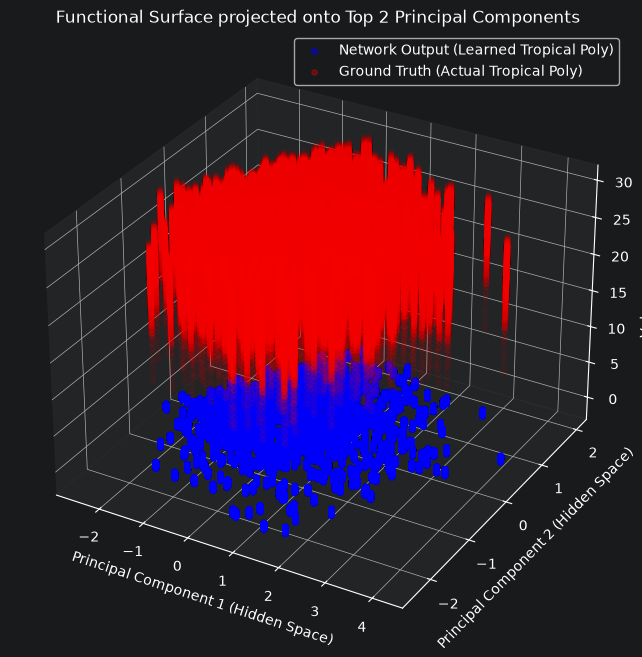

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Setup Mock Network and Data (n=10 variables)
n_variables = 10
model = nn.Sequential(
    nn.Linear(n_variables, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    # We will capture the output of this layer
)
final_layer = nn.Linear(16, 1)

# Generate a batch of random item lists (inputs) and mock ground truth
X_data = torch.rand(1000, n_variables) * 10
# (Mocking the ground truth subset sum values for the sake of example)
y_ground_truth = torch.sum(torch.topk(X_data, k=3, dim=1).values, dim=1, keepdim=True)

# 2. Evaluate and Capture Hidden States
model.eval()
with torch.no_grad():
    hidden_states = model(X_data)
    network_predictions = final_layer(hidden_states)

# 3. Perform PCA on the Hidden States
# We reduce the 16-dimensional hidden space down to 2 dimensions
pca = PCA(n_components=2)
hidden_states_2d = pca.fit_transform(hidden_states.numpy())

pc1 = hidden_states_2d[:, 0]
pc2 = hidden_states_2d[:, 1]

# 4. Visualize the Functional Surface over the Principal Components
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the network's learned surface (The CPWL hinges)
ax.scatter(pc1, pc2, network_predictions.numpy(),
           c='blue', alpha=0.5, label='Network Output (Learned Tropical Poly)', s=15)

# Plot the ground truth mapped to the same hidden PCA space
ax.scatter(pc1, pc2, y_ground_truth.numpy(),
           c='red', alpha=0.3, label='Ground Truth (Actual Tropical Poly)', s=15)

ax.set_title('Functional Surface projected onto Top 2 Principal Components')
ax.set_xlabel('Principal Component 1 (Hidden Space)')
ax.set_ylabel('Principal Component 2 (Hidden Space)')
ax.set_zlabel('Value / Output')
ax.legend()
plt.show()